In [1]:
#importing necessary files
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#data generation
def generate_realistic_data(mode="mixed", n=200, noise=0.1, imbalance=False):
    np.random.seed(42)

    if mode == "gaussian_overlap":
        class0 = np.random.randn(n, 2) * 1.5 + np.array([2, 2])
        class1 = np.random.randn(n, 2) * 1.5 + np.array([4, 4])

        X = np.vstack((class0, class1))
        y = np.array([0]*n + [1]*n)

    elif mode == "nonlinear_circle":
        r = np.random.rand(n) * 5
        theta = np.random.rand(n) * 2 * np.pi

        X = np.c_[r * np.cos(theta), r * np.sin(theta)]
        y = (r > 2.5).astype(int)

        return X, y  # early return is fine here

    elif mode == "moons_like":
        theta = np.linspace(0, np.pi, n)

        x1 = np.c_[np.cos(theta), np.sin(theta)] + np.random.randn(n,2)*0.2
        x2 = np.c_[1 - np.cos(theta), 1 - np.sin(theta)] + np.random.randn(n,2)*0.2

        X = np.vstack((x1, x2))
        y = np.array([0]*n + [1]*n)

    else:  # mixed
        class0 = np.random.randn(n, 2) * 1.2 + np.array([2, 2])
        class1 = np.random.randn(n, 2) * 1.2 + np.array([4, 4])

        swirl = np.random.randn(n, 2)
        class1 += np.c_[np.sin(swirl[:,0]), np.cos(swirl[:,1])]

        if imbalance:
            class1 = class1[:int(0.6 * n)]

        X = np.vstack((class0, class1))
        y = np.array([0]*len(class0) + [1]*len(class1))

    # Add label noise (for all modes except circle)
    num_noisy = int(noise * len(y))
    idx = np.random.choice(len(y), num_noisy, replace=False)
    y[idx] = 1 - y[idx]

    return X, y

In [3]:
#gini impurity
def gini(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return 1 - np.sum(probs**2)

#split function
def split(X, y, feature, threshold):
    
    left_idx = X[:, feature] <= threshold
    right_idx = X[:, feature] > threshold

    return (X[left_idx], y[left_idx]), (X[right_idx], y[right_idx])


#best Split
def best_split(X, y):
    best_gini = float('inf')
    best_feature = None
    best_threshold = None

    n_features = X.shape[1]

    for feature in range(n_features):
        thresholds = np.unique(X[:, feature])

        for t in thresholds:
            (X_l, y_l), (X_r, y_r) = split(X, y, feature, t)

            if len(y_l) == 0 or len(y_r) == 0:
                continue

            g = (len(y_l)/len(y))*gini(y_l) + (len(y_r)/len(y))*gini(y_r)

            if g < best_gini:
                best_gini = g
                best_feature = feature
                best_threshold = t

    return best_feature, best_threshold

In [4]:
#NODE
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

# Build the tree
def build_tree(X, y, depth=0, max_depth=3, min_samples_split=20):
    if len(np.unique(y)) == 1:
        return Node(value=y[0])
    if depth >= max_depth or len(y) < min_samples_split:
        return Node(value=np.bincount(y).argmax())
    feature, threshold = best_split(X, y)
    if feature is None:
        return Node(value=np.bincount(y).argmax())
    (X_l, y_l), (X_r, y_r) = split(X, y, feature, threshold)
    # Fixed: Passing min_samples_split recursively
    left = build_tree(X_l, y_l, depth + 1, max_depth, min_samples_split)
    right = build_tree(X_r, y_r, depth + 1, max_depth, min_samples_split)
    return Node(feature, threshold, left, right)


# prediction
def predict_one(node, x):
    if node.value is not None:
        return node.value

    if x[node.feature] <= node.threshold:
        return predict_one(node.left, x)
    else:
        return predict_one(node.right, x)


def predict(tree, X):
    return np.array([predict_one(tree, x) for x in X])


# prediction
def predict_one(node, x):
    if node.value is not None:
        return node.value

    if x[node.feature] <= node.threshold:
        return predict_one(node.left, x)
    else:
        return predict_one(node.right, x)


def predict(tree, X):
    return np.array([predict_one(tree, x) for x in X])

#prediction
def predict_one(node, x):
    if node.value is not None:
        return node.value

    if x[node.feature] <= node.threshold:
        return predict_one(node.left, x)
    else:
        return predict_one(node.right, x)


def predict(tree, X):
    return np.array([predict_one(tree, x) for x in X])

In [5]:
#decision boundary
def plot_boundary(tree, X, y):

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    Z = np.zeros(xx.shape)

    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            point = np.array([xx[i,j], yy[i,j]])
            Z[i,j] = predict_one(tree, point)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.title("Decision Boundary")
    plt.show()

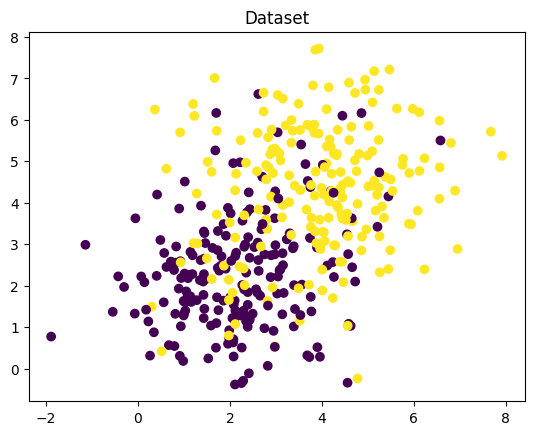

Accuracy: 0.835


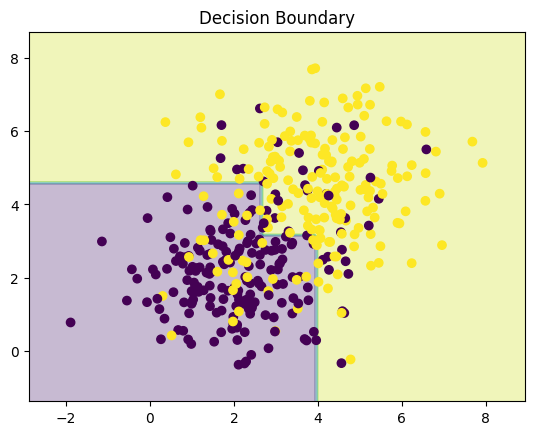

Depth=1, Accuracy=0.78
Depth=3, Accuracy=0.83
Depth=5, Accuracy=0.85
Depth=10, Accuracy=0.88


In [6]:
#The pipeline
# 1. Generate data
X, y = generate_realistic_data()

# 2. Visualize
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Dataset")
plt.show()

# 3. Train tree
tree = build_tree(X, y, max_depth=3)

# 4. Predict
preds = predict(tree, X)

# 5. Accuracy
accuracy = np.mean(preds == y)
print("Accuracy:", accuracy)

# 6. Plot decision boundary
plot_boundary(tree, X, y)
#depth vs Overfitting
for depth in [1, 3, 5, 10]:
    tree = build_tree(X, y, max_depth=depth)
    preds = predict(tree, X)
    acc = np.mean(preds == y)
    print(f"Depth={depth}, Accuracy={acc:.2f}")

Decision Tree related info
Depth -> number of splits from root to leaf
example 
-

Depth = 0      [Root]
               /   \
Depth = 1   [Node] [Node]
             /  \
Depth = 2 [Leaf][Leaf]
-
small depth -> few splits,  simple decision rules, cannot capture complex patterns thus causing under fitting i.e. high bias, low variance. Lack of understanding of the data 

large depth -> many splits,  very specifc rules, can memorize training data thus causing overfitting i.e. low bias, high variance. Can cause model to learn noise